# 01 — Data Understanding and Exploration

## 1. Study Context and Continuous Regression Objective

Concrete compressive strength is a central quantitative property used to characterize concrete performance. The **Concrete Compressive Strength** dataset from the UCI Machine Learning Repository provides **1,030 observations** described by **eight quantitative input variables**: seven concrete-mixture component quantities and curing age. The response is the measured **concrete compressive strength in MPa**.

The primary analytical objective of this study is to estimate concrete compressive strength as a **continuous numerical target** from the available mixture composition and age variables. The target will therefore remain on its original quantitative scale rather than being discretized into strength classes or converted into a classification problem.

The dataset authors describe compressive strength as a highly nonlinear function of age and ingredients. This makes the dataset a useful reference case for studying **continuous regression**, where predictive quality depends not only on detecting association but also on representing nonlinear relationships, interactions, differing feature scales, and the magnitude of numerical prediction errors.

This first notebook is intentionally limited to **data understanding and exploratory analysis**. It will establish the empirical evidence needed for later preparation and modeling decisions without fitting or selecting predictive models. Particular attention will be given to data quality, the distribution and range of the continuous target, numerical feature behavior, feature redundancy, feature-to-target relationships, possible nonlinear structure, repeated observations, and potential sources of leakage.

The analysis is predictive rather than causal. Associations observed between mixture components, age, and compressive strength should not by themselves be interpreted as causal effects, engineering design rules, or evidence that changing one component while holding all others fixed would produce the same effect in practice.

The study is guided by the following questions:

- What is the observed distribution, range, and concentration of concrete compressive strength, and are there extreme target values that may materially affect regression evaluation?
- How do the available mixture components and curing age relate to the continuous target, and which relationships appear linear, monotonic, nonlinear, or interaction-dependent?
- Which input variables are strongly related or structurally redundant, and what implications might those relationships have for later preparation and model selection?
- Are there duplicate or repeated observational profiles that could create optimistic validation if later data partitions are constructed without accounting for them?
- Which exploratory findings should guide the later split strategy, preprocessing policy, regression metrics, candidate model families, and final evaluation protocol?

## 2. Dataset Source and Acquisition

In [1]:
import pandas as pd

from scripts.download_data import acquire_uci_dataset
from scripts.project_context import get_project_context


# Dataset-specific source choices remain visible in the notebook.
DATASET_SLUG = "concrete-compressive-strength"
UCI_DATASET_ID = 165

PROJECT = get_project_context()
RAW_DATA_DIR = PROJECT.path("data", "raw", DATASET_SLUG)

acquisition = acquire_uci_dataset(
    dataset_id=UCI_DATASET_ID,
    destination=RAW_DATA_DIR,
    project_root=PROJECT.root,
)

DATASET_FILE = acquisition.require_one_file("dataset.csv")
df = pd.read_csv(DATASET_FILE)

print(f"Dataset source: UCI ML Repository — ID {UCI_DATASET_ID}")
print(f"Raw data directory: {PROJECT.display(RAW_DATA_DIR)}")
print(f"Dataset file: {DATASET_FILE.name}")
print(f"Loaded shape: {df.shape}")

Dataset source: UCI ML Repository — ID 165
Raw data directory: data/raw/concrete-compressive-strength
Dataset file: dataset.csv
Loaded shape: (1030, 9)


## 3. Unit of Observation

In [2]:
from scripts.validate_data import analyze_observation_unit


# Dataset-specific analytical definition remains visible.
OBSERVATION_LABEL = (
    "concrete mix composition evaluated at a specified curing age "
    "with measured compressive strength"
)
OBSERVATION_IDENTIFIER = None

observation_report = analyze_observation_unit(
    dataframe=df,
    identifier=OBSERVATION_IDENTIFIER,
)

print(f"Unit of observation: {OBSERVATION_LABEL}")
observation_report.summary_frame()

Unit of observation: concrete mix composition evaluated at a specified curing age with measured compressive strength


,Metric,Value
0,Rows,1030
1,Source identifier,Not provided
2,Identifier completeness,Not assessable
3,Identifier uniqueness,Not assessable


## 4. Dataset Structure and Source Identity

In [3]:
from IPython.display import display

from scripts.describe_dataset import describe_dataset_structure


structure_report = describe_dataset_structure(
    df,
    acquisition=acquisition,
    expected_source_id=UCI_DATASET_ID,
)

display(structure_report.summary_frame())
display(structure_report.columns_frame())

,Metric,Value
0,Dataset,Concrete Compressive Strength
1,Source,UCI Machine Learning Repository
2,Source dataset ID,165
3,DOI,10.24432/C5PK67
4,Rows,1030
5,Columns,9
6,Source-declared instances,1030
7,Materialized data file,data/raw/concrete-compressive-strength/dataset...


,Position,Column
0,1,Cement
1,2,Blast Furnace Slag
2,3,Fly Ash
3,4,Water
4,5,Superplasticizer
5,6,Coarse Aggregate
6,7,Fine Aggregate
7,8,Age
8,9,Concrete compressive strength


## 5. Target and Continuous Regression Prediction Contract

In [4]:
from IPython.display import display

from scripts.target_contract import define_continuous_regression_target_contract


# Dataset-specific prediction semantics remain explicit in the notebook.
TARGET_COLUMN = "Concrete compressive strength"
PROBLEM_TYPE = "continuous_regression"
TARGET_SEMANTICS = "Continuous / quantitative"
TARGET_UNIT = "MPa"
SOURCE_TARGET_TYPE = "Continuous"

target_contract = define_continuous_regression_target_contract(
    df,
    target=TARGET_COLUMN,
    problem_type=PROBLEM_TYPE,
    target_semantics=TARGET_SEMANTICS,
    expected_unit=TARGET_UNIT,
    expected_source_type=SOURCE_TARGET_TYPE,
    source_variables_file=acquisition.require_one_file("variables.csv"),
)

display(target_contract.summary_frame())

,Contract item,Value,Interpretation
0,Problem type,continuous_regression,Supervised continuous regression task
1,Target column,Concrete compressive strength,Continuous outcome to be predicted
2,Target semantics,Continuous / quantitative,Quantitative target; not a class label
3,Prediction output,Continuous numeric value on the original targe...,No thresholding or class decoding applies
4,Target unit,MPa,Unit of the original prediction scale
5,Source variable role,Target,Role declared by source metadata
6,Source variable type,Continuous,Type declared by source metadata
7,Contract status,Valid,"Target exists, is numeric, and matches declare..."


## 6. Feature Roles and Data Dictionary

In [5]:
from scripts.feature_dictionary import define_feature_roles_and_dictionary


feature_dictionary = define_feature_roles_and_dictionary(
    df,
    source_variables_file=acquisition.require_one_file("variables.csv"),
    target=target_contract.target,
    identifiers=OBSERVATION_IDENTIFIER,
)

FEATURE_COLUMNS = feature_dictionary.feature_columns
IDENTIFIER_COLUMNS = feature_dictionary.identifier_columns

display(feature_dictionary.summary_frame())
feature_dictionary.column_frame()

,Metric,Value
0,Candidate features,8
1,Identifiers,0
2,Targets,1
3,Columns covered by source metadata,9
4,Columns with source descriptions,0


,Column,Analytical role,Source role,Description,Unit
0,Cement,Candidate feature,Feature,Not documented by source,kg/m^3
1,Blast Furnace Slag,Candidate feature,Feature,Not documented by source,kg/m^3
2,Fly Ash,Candidate feature,Feature,Not documented by source,kg/m^3
3,Water,Candidate feature,Feature,Not documented by source,kg/m^3
4,Superplasticizer,Candidate feature,Feature,Not documented by source,kg/m^3
5,Coarse Aggregate,Candidate feature,Feature,Not documented by source,kg/m^3
6,Fine Aggregate,Candidate feature,Feature,Not documented by source,kg/m^3
7,Age,Candidate feature,Feature,Not documented by source,day
8,Concrete compressive strength,Target,Target,Not documented by source,MPa


## 7. Data Types, Ranges, and Domain Validity

In [6]:
from scripts.validate_domains import analyze_types_ranges_and_domains


# Dataset-specific physical and source-documented constraints remain visible.
DOMAIN_RULES = {
    "non_negative": (
        "Cement",
        "Blast Furnace Slag",
        "Fly Ash",
        "Water",
        "Superplasticizer",
        "Coarse Aggregate",
        "Fine Aggregate",
        "Concrete compressive strength",
    ),
    "minimums": {
        "Age": 1.0,
    },
    "maximums": {
        "Age": 365.0,
    },
}

domain_report = analyze_types_ranges_and_domains(
    df,
    source_variables_file=acquisition.require_one_file("variables.csv"),
    domain_rules=DOMAIN_RULES,
)

display(domain_report.summary_frame())
display(domain_report.column_frame())
domain_report.relation_frame()

,Metric,Value
0,Columns with source-backed type expectations,9
1,Type mismatches,1
2,Columns with declared domain expectations,9
3,Columns with domain violations,0
4,Declared cross-column relations,0
5,Relations with violations,0


,Column,Source type,Expected type,Observed dtype,Observed minimum,Observed maximum,Domain expectation,Violation count,Status
0,Cement,Continuous,numeric,float64,102.00,540.0,>= 0,0,Valid
1,Blast Furnace Slag,Integer,integer,float64,0.00,359.4,>= 0,0,Review required
2,Fly Ash,Continuous,numeric,float64,0.00,200.1,>= 0,0,Valid
3,Water,Continuous,numeric,float64,121.80,247.0,>= 0,0,Valid
4,Superplasticizer,Continuous,numeric,float64,0.00,32.2,>= 0,0,Valid
5,Coarse Aggregate,Continuous,numeric,float64,801.00,1145.0,>= 0,0,Valid
6,Fine Aggregate,Continuous,numeric,float64,594.00,992.6,>= 0,0,Valid
7,Age,Integer,integer,int64,1.00,365.0,>= 1; <= 365,0,Valid
8,Concrete compressive strength,Continuous,numeric,float64,2.33,82.6,>= 0,0,Valid


,Relation,Evaluated rows,Violation count,Status


## 8. Missing and Invalid Values

In [7]:
from scripts.validate_values import analyze_source_backed_missing_and_invalid_values


value_quality_report = analyze_source_backed_missing_and_invalid_values(
    df,
    source_variables_file=acquisition.require_one_file("variables.csv"),
    target=target_contract.target,
)

# In exploration, discovered issues remain evidence rather than being mutated away.
value_quality_report.raise_if_invalid(require_no_quality_issues=False)

display(value_quality_report.summary_frame())
display(value_quality_report.column_frame())
value_quality_report.issues_with_impacts_frame()

,Status,Column count
0,Valid,8
1,Review required,1
2,Not assessed,0
3,Missing column,0


,Column,Row count,Missing count,Blank count,Inconsistent count,Invalid count,Affected count,Affected percent,Issue types,Status
0,Cement,1030,0,0,0,0,0,0.000,,Valid
1,Blast Furnace Slag,1030,0,0,0,298,298,28.932,Non-integer value,Review required
2,Fly Ash,1030,0,0,0,0,0,0.000,,Valid
3,Water,1030,0,0,0,0,0,0.000,,Valid
4,Superplasticizer,1030,0,0,0,0,0,0.000,,Valid
5,Coarse Aggregate,1030,0,0,0,0,0,0.000,,Valid
6,Fine Aggregate,1030,0,0,0,0,0,0.000,,Valid
7,Age,1030,0,0,0,0,0,0.000,,Valid
8,Concrete compressive strength,1030,0,0,0,0,0,0.000,,Valid


,Column,Issue,Raw value,Count,Potential analytical impact
0,Blast Furnace Slag,Non-integer value,106.3,20,Violates a source-declared integer field and m...
1,Blast Furnace Slag,Non-integer value,98.1,10,Violates a source-declared integer field and m...
2,Blast Furnace Slag,Non-integer value,132.4,6,Violates a source-declared integer field and m...
3,Blast Furnace Slag,Non-integer value,142.5,6,Violates a source-declared integer field and m...
4,Blast Furnace Slag,Non-integer value,203.5,6,Violates a source-declared integer field and m...
5,Blast Furnace Slag,Non-integer value,209.4,6,Violates a source-declared integer field and m...
6,Blast Furnace Slag,Non-integer value,237.5,6,Violates a source-declared integer field and m...
7,Blast Furnace Slag,Non-integer value,47.5,6,Violates a source-declared integer field and m...
8,Blast Furnace Slag,Non-integer value,97.1,6,Violates a source-declared integer field and m...
9,Blast Furnace Slag,Non-integer value,117.2,5,Violates a source-declared integer field and m...


## 9. Duplicate Records

In [8]:
from scripts.validate_duplicates import analyze_duplicate_records


duplicate_report = analyze_duplicate_records(
    df,
    identifiers=IDENTIFIER_COLUMNS,
    feature_columns=FEATURE_COLUMNS,
    target=target_contract.target,
    max_group_samples=10,
)

display(duplicate_report.summary_frame())

if not duplicate_report.has_source_identifiers:
    print(
        "Source identifiers are not available. Exact row matches are "
        "review evidence, not proof that the same concrete observation "
        "was recorded twice."
    )

if duplicate_report.has_exact_duplicates:
    print("Sample of exact row matches:")
    display(duplicate_report.exact_duplicates_frame())

if duplicate_report.has_repeated_profiles:
    print("Sample of repeated candidate-feature profiles:")
    display(duplicate_report.repeated_profiles_frame())

if duplicate_report.has_target_conflicts:
    print(
        "Some identical feature profiles map to different compressive-strength "
        "values. Treat these cases as analytical ambiguity or observed "
        "measurement/process variability rather than automatic data-quality "
        "errors."
    )
    display(duplicate_report.target_conflicts_frame())

# Without source identifiers, equality alone does not justify dropping rows.
duplicate_report.raise_if_invalid(
    require_no_exact_duplicates=bool(IDENTIFIER_COLUMNS),
    require_unique_identifiers=bool(IDENTIFIER_COLUMNS),
    require_no_conflicting_identifiers=bool(IDENTIFIER_COLUMNS),
    require_no_repeated_profiles=False,
    require_no_target_conflicts=False,
)

,Metric,Group count,Row count,Interpretation
0,Exact duplicate records,11,36,Review required; source identity unavailable
1,Duplicate identifiers,0,0,Not applicable; source identifier unavailable
2,Conflicting duplicate identifiers,0,0,Not applicable; source identifier unavailable
3,Repeated feature profiles,19,57,Potentially valid repeated records
4,Repeated profiles with the same target,10,33,Valid repeated profile
5,Repeated profiles with target disagreement,9,24,Analytical ambiguity


Source identifiers are not available. Exact row matches are review evidence, not proof that the same concrete observation was recorded twice.
Sample of exact row matches:


,Group,Group size,Row position,Row index,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,1,3,72,72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3.0,33.40
1,1,3,77,77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3.0,33.40
2,1,3,80,80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3.0,33.40
3,2,4,83,83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
4,2,4,86,86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
5,2,4,88,88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
6,2,4,91,91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,35.30
7,3,3,95,95,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7.0,49.20
8,3,3,100,100,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7.0,49.20
9,3,3,103,103,425.0,106.3,0.0,153.5,16.5,852.1,887.1,7.0,49.20


Sample of repeated candidate-feature profiles:


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,1,3,<NA>,np.float64(33.4),1,Same target,"(72, 77, 80)","(72, 77, 80)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
1,2,4,<NA>,np.float64(35.3),1,Same target,"(83, 86, 88, 91)","(83, 86, 88, 91)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
2,3,3,<NA>,np.float64(49.2),1,Same target,"(95, 100, 103)","(95, 100, 103)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
3,4,4,<NA>,"np.float64(55.9), np.float64(22.9)",2,Target disagreement,"(106, 109, 111, 114)","(106, 109, 111, 114)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
4,5,3,<NA>,np.float64(60.29),1,Same target,"(118, 123, 126)","(118, 123, 126)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
5,6,4,<NA>,np.float64(71.3),1,Same target,"(129, 132, 134, 137)","(129, 132, 134, 137)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
6,7,3,<NA>,np.float64(64.3),1,Same target,"(141, 146, 149)","(141, 146, 149)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
7,8,4,<NA>,np.float64(77.3),1,Same target,"(152, 155, 157, 160)","(152, 155, 157, 160)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."
8,9,3,<NA>,np.float64(65.2),1,Same target,"(164, 169, 172)","(164, 169, 172)","{'Cement': 425.0, 'Blast Furnace Slag': 106.3,..."
9,10,4,<NA>,np.float64(79.3),1,Same target,"(175, 177, 179, 182)","(175, 177, 179, 182)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."


Some identical feature profiles map to different compressive-strength values. Treat these cases as analytical ambiguity or observed measurement/process variability rather than automatic data-quality errors.


,Profile group,Row count,Distinct identifier count,Target values,Target value count,Classification,Row positions,Row indices,Feature values
0,4,4,<NA>,"np.float64(55.9), np.float64(22.9)",2,Target disagreement,"(106, 109, 111, 114)","(106, 109, 111, 114)","{'Cement': 362.6, 'Blast Furnace Slag': 189.0,..."


## 10. Target Distribution, Range, and Extremes

,Metric,Value,Interpretation
0,Total rows,1030.000000,All observations
1,Finite target values,1030.000000,Rows used for numerical summaries
2,Missing target values,0.000000,No missing target values
3,Non-finite target values,0.000000,All non-missing target values are finite
4,Distinct finite values,845.000000,Observed target-value diversity
5,Minimum,2.330000,Observed minimum (MPa)
6,Mean,35.817961,Arithmetic mean (MPa)
7,Median,34.445000,50th percentile (MPa)
8,Maximum,82.600000,Observed maximum (MPa)
9,Observed range,80.270000,Maximum minus minimum (MPa)


,Quantile,Value,Unit
0,1%,6.8858,MPa
1,5%,10.9610,MPa
2,25%,23.7100,MPa
3,50%,34.4450,MPa
4,75%,46.1350,MPa
5,95%,66.8020,MPa
6,99%,77.3000,MPa


,Side,Fence,Observed extreme,Count outside fence
0,Lower,-9.9275,2.33,0
1,Upper,79.7725,82.60,4


Values outside the 1.5-IQR fences are descriptive extreme-value signals only; they are not automatic outlier-removal candidates.


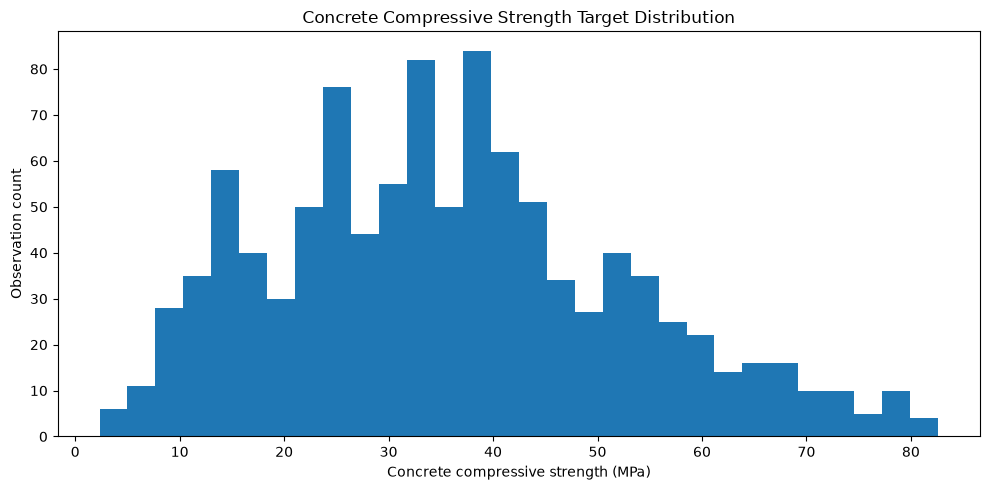

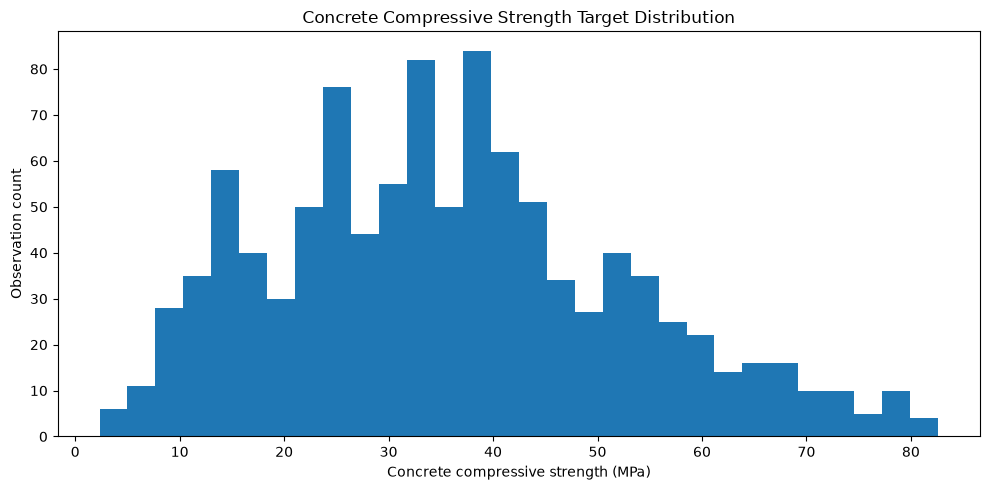

In [9]:
from scripts.export_figures import export_figure
from scripts.analyze_target import (
    analyze_continuous_target_distribution,
    plot_continuous_target_distribution,
)


target_distribution_report = analyze_continuous_target_distribution(
    df,
    target=target_contract.target,
    unit=TARGET_UNIT,
)

# Revalidate the continuous target before interpreting its distribution.
target_distribution_report.raise_if_invalid()

display(target_distribution_report.summary_frame())
display(target_distribution_report.quantiles_frame())
display(target_distribution_report.extremes_frame())

print(
    "Values outside the 1.5-IQR fences are descriptive extreme-value "
    "signals only; they are not automatic outlier-removal candidates."
)

target_distribution_figure = plot_continuous_target_distribution(
    target_distribution_report,
    title="Concrete Compressive Strength Target Distribution",
    bins=30,
)
export_figure(
    target_distribution_figure,
    PROJECT.root / "docs/images/target_distribution.png",
)
target_distribution_figure

## 11. Numerical Feature Exploration

,Feature,Minimum,Q1,Median,Mean,Q3,Maximum,Standard deviation,IQR,Skewness,Distribution shape,Outlier count,Outlier percent
0,Cement,102.0,192.375,272.9,281.167864,350.00,540.0,104.506364,157.625,0.509481,Right-skewed,0,0.00%
1,Blast Furnace Slag,0.0,0.000,22.0,73.895825,142.95,359.4,86.279342,142.950,0.800717,Right-skewed,2,0.19%
2,Fly Ash,0.0,0.000,0.0,54.188350,118.30,200.1,63.997004,118.300,0.537354,Right-skewed,0,0.00%
3,Water,121.8,164.900,185.0,181.567282,192.00,247.0,21.354219,27.100,0.074628,Approximately symmetric,9,0.87%
4,Superplasticizer,0.0,0.000,6.4,6.204660,10.20,32.2,5.973841,10.200,0.907203,Right-skewed,10,0.97%
5,Coarse Aggregate,801.0,932.000,968.0,972.918932,1029.40,1145.0,77.753954,97.400,-0.040220,Approximately symmetric,0,0.00%
6,Fine Aggregate,594.0,730.950,779.5,773.580485,824.00,992.6,80.175980,93.050,-0.253010,Approximately symmetric,5,0.49%
7,Age,1.0,7.000,28.0,45.662136,56.00,365.0,63.169912,49.000,3.269177,Right-skewed,59,5.73%


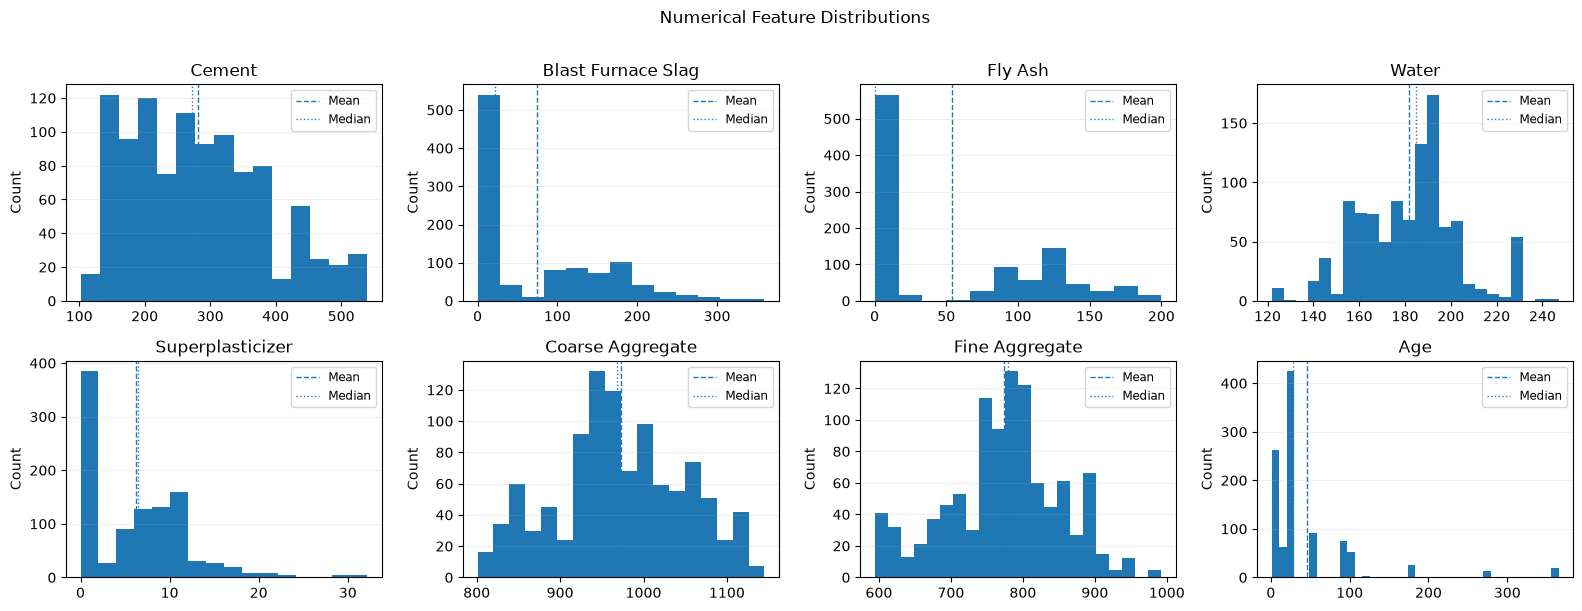

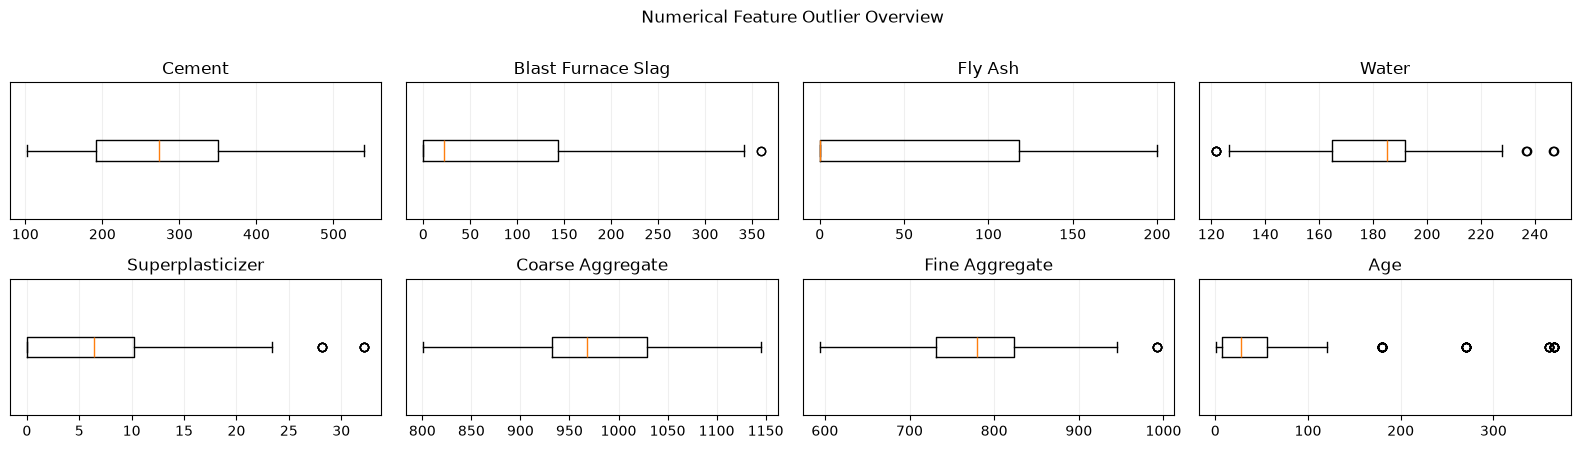

IQR candidates are descriptive evidence only; no rows are removed or clipped during exploration.


,Feature,Lower fence,Upper fence,Lower outlier count,Upper outlier count,Outlier count,Outlier percent,Interpretation
0,Cement,-44.0625,586.4375,0,0,0,0.000000,No IQR outlier candidates
1,Blast Furnace Slag,-214.4250,357.3750,0,2,2,0.001942,Candidate outliers require contextual review
2,Fly Ash,-177.4500,295.7500,0,0,0,0.000000,No IQR outlier candidates
3,Water,124.2500,232.6500,5,4,9,0.008738,Candidate outliers require contextual review
4,Superplasticizer,-15.3000,25.5000,0,10,10,0.009709,Candidate outliers require contextual review
5,Coarse Aggregate,785.9000,1175.5000,0,0,0,0.000000,No IQR outlier candidates
6,Fine Aggregate,591.3750,963.5750,0,5,5,0.004854,Candidate outliers require contextual review
7,Age,-66.5000,129.5000,0,59,59,0.057282,Candidate outliers require contextual review


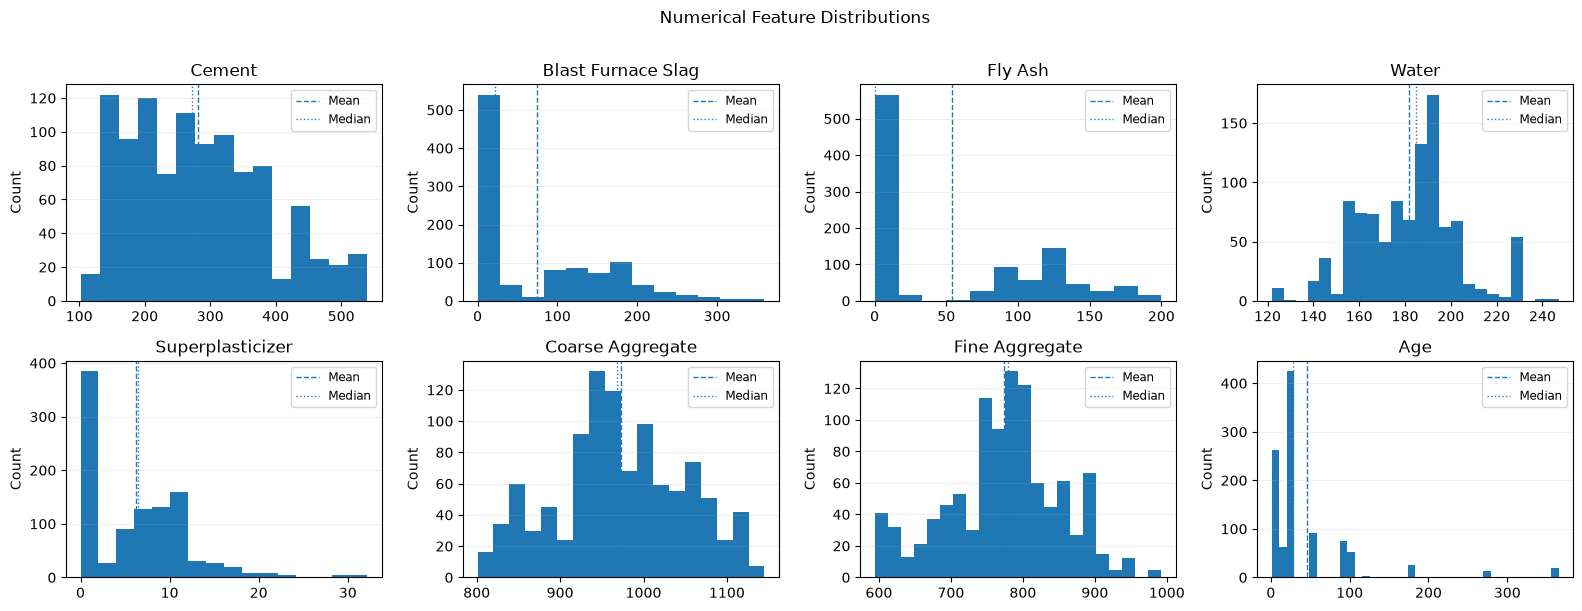

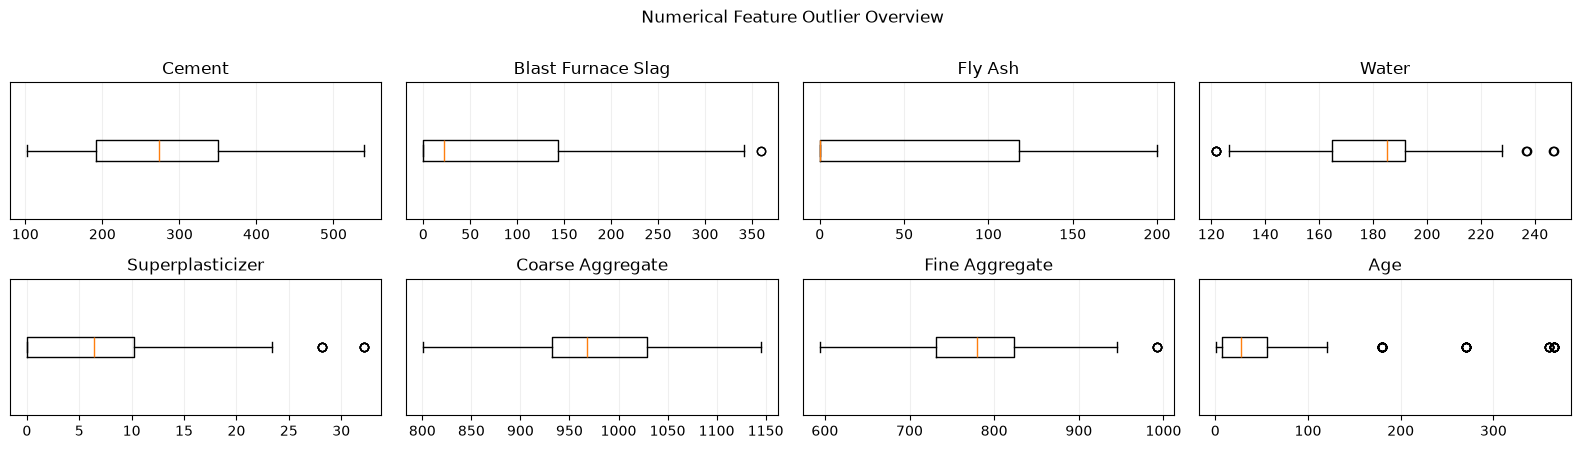

In [10]:
from IPython.display import display

from scripts.analyze_numerical import (
    analyze_numerical_features,
    plot_numerical_boxplots,
    plot_numerical_distributions,
)


# The validated candidate-feature set is entirely numerical for Concrete.
NUMERICAL_FEATURES = FEATURE_COLUMNS

# Explicit exploratory heuristics; neither one changes the raw data.
IQR_MULTIPLIER = 1.5
SKEWNESS_REVIEW_THRESHOLD = 0.5

numerical_report = analyze_numerical_features(
    df,
    features=NUMERICAL_FEATURES,
    iqr_multiplier=IQR_MULTIPLIER,
)

numerical_report.raise_if_invalid(
    require_features_present=True,
    require_numeric_conversion=True,
    require_materialization_conditions=True,
    require_no_missing_values=True,
    require_no_outliers=False,
)

display(
    numerical_report.exploration_frame(
        skewness_review_threshold=SKEWNESS_REVIEW_THRESHOLD,
    )
)

distribution_figure = plot_numerical_distributions(
    numerical_report,
    columns=4,
)
display(distribution_figure)

outlier_figure = plot_numerical_boxplots(
    numerical_report,
    columns=4,
)
display(outlier_figure)

if numerical_report.has_outliers:
    print(
        "IQR candidates are descriptive evidence only; no rows are removed "
        "or clipped during exploration."
    )
    display(numerical_report.outlier_summary_frame())

## 12. Feature Relationships and Redundancy

,Metric,Value,Interpretation
0,Numerical features,8.0,Candidate features included in the analysis
1,Feature pairs,28.0,Unique numerical feature pairs assessed
2,Strong-association threshold,0.8,Absolute Pearson or rank correlation used for ...
3,Strong-association pairs,0.0,Pairs meeting the exploratory threshold
4,Redundancy-review threshold,0.9,Absolute Pearson correlation used to flag redu...
5,Redundancy-review candidates,0.0,Review evidence only; no feature removal is im...


No feature pairs reached the strong-association review threshold.


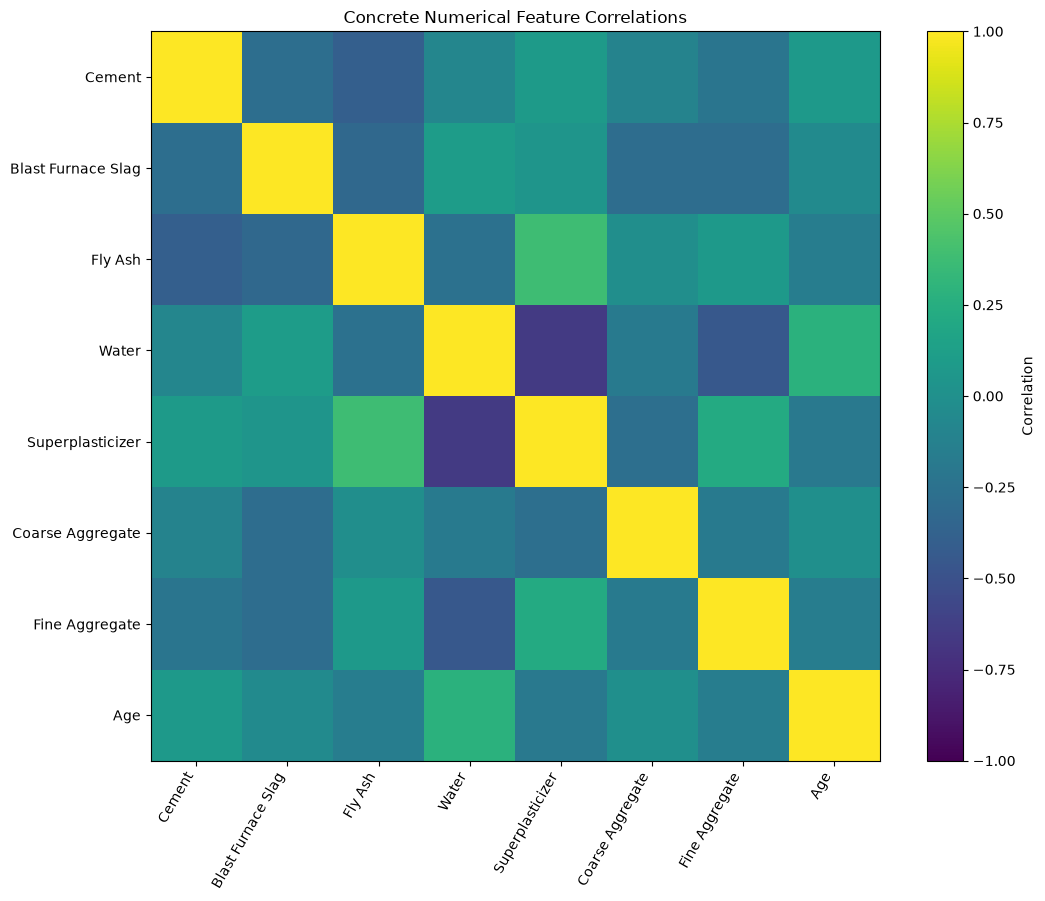

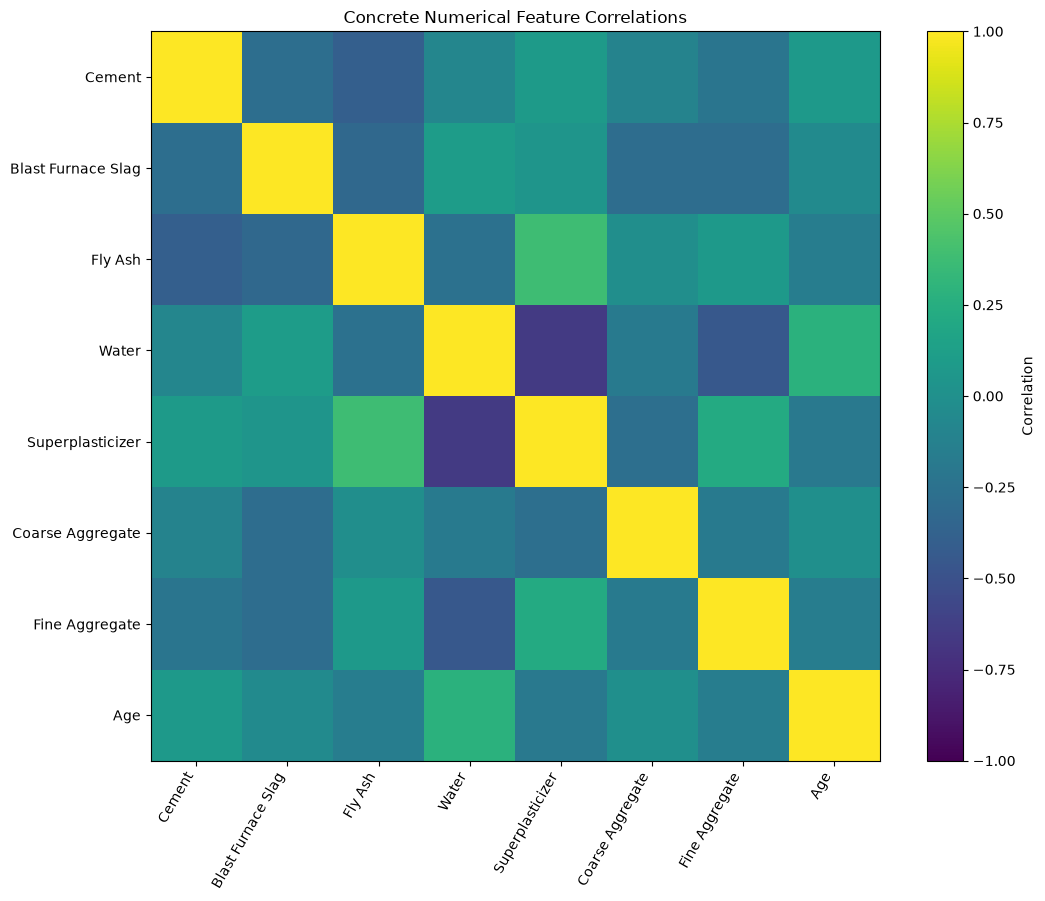

In [11]:
from scripts.analyze_relationships import (
    analyze_numerical_feature_relationships,
    plot_numerical_correlation_heatmap,
)
from scripts.export_figures import export_figure


# Exploratory thresholds remain explicit; they flag review candidates only.
STRONG_FEATURE_ASSOCIATION_THRESHOLD = 0.80
REDUNDANCY_REVIEW_THRESHOLD = 0.90

feature_relationship_report = analyze_numerical_feature_relationships(
    df,
    features=NUMERICAL_FEATURES,
    strong_association_threshold=STRONG_FEATURE_ASSOCIATION_THRESHOLD,
    redundancy_review_threshold=REDUNDANCY_REVIEW_THRESHOLD,
)

feature_relationship_report.raise_if_invalid(
    require_features_present=True,
    require_sufficient_variation=True,
)

display(feature_relationship_report.numerical_summary_frame())

relationship_review = feature_relationship_report.numerical_review_frame()
if relationship_review.empty:
    print("No feature pairs reached the strong-association review threshold.")
else:
    display(relationship_review)

correlation_figure = plot_numerical_correlation_heatmap(
    feature_relationship_report,
    method="pearson",
    title="Concrete Numerical Feature Correlations",
)
export_figure(
    correlation_figure,
    PROJECT.root / "docs/images/numerical_feature_correlation_heatmap.png",
)
display(correlation_figure)

if feature_relationship_report.has_redundancy_candidates:
    print(
        "High association marks redundancy candidates for later review; "
        "no feature is removed during exploration."
    )

## 13. Feature-to-Target Relationships

,Metric,Value,Interpretation
0,Rows,1030,Observations supplied to the analysis
1,Numerical features,8,Candidate numerical features requested
2,Target,Concrete compressive strength (MPa),Continuous regression outcome
3,Target unique values,845,Observed finite numerical target values
4,Association review threshold,0.3,"Applied to max(|Pearson|, |Spearman|); review ..."
5,Review candidates,4,Features meeting the exploratory association t...


,Feature,Valid paired rows,Excluded paired rows,Pearson correlation,Spearman correlation,Absolute Pearson correlation,Absolute Spearman correlation,Maximum absolute association,Review flag,Interpretation
0,Age,1030,0,0.328873,0.596028,0.328873,0.596028,0.596028,True,Meets the exploratory univariate association r...
1,Cement,1030,0,0.497832,0.477614,0.497832,0.477614,0.497832,True,Meets the exploratory univariate association r...
2,Superplasticizer,1030,0,0.366079,0.347786,0.366079,0.347786,0.366079,True,Meets the exploratory univariate association r...
3,Water,1030,0,-0.289633,-0.308414,0.289633,0.308414,0.308414,True,Meets the exploratory univariate association r...
4,Coarse Aggregate,1030,0,-0.164935,-0.183542,0.164935,0.183542,0.183542,False,Below the exploratory univariate association r...
5,Fine Aggregate,1030,0,-0.167241,-0.179962,0.167241,0.179962,0.179962,False,Below the exploratory univariate association r...
6,Blast Furnace Slag,1030,0,0.134829,0.164105,0.134829,0.164105,0.164105,False,Below the exploratory univariate association r...
7,Fly Ash,1030,0,-0.105755,-0.077830,0.105755,0.077830,0.105755,False,Below the exploratory univariate association r...


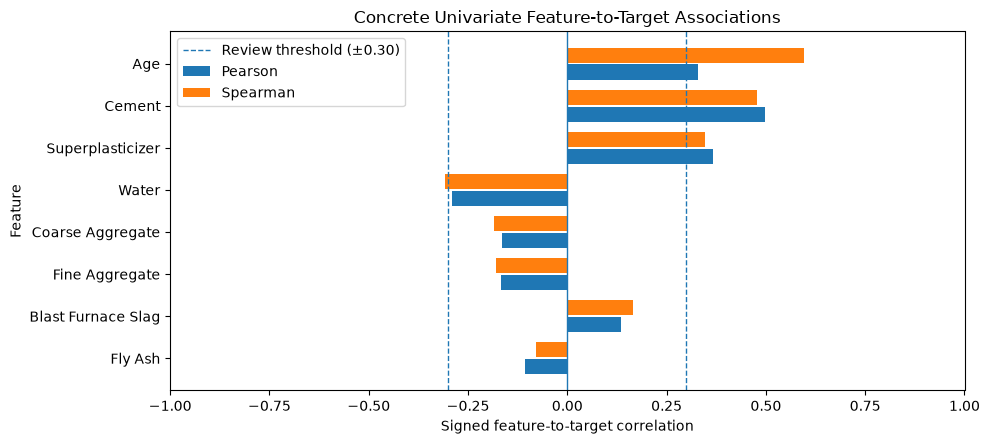

Review candidates show univariate linear or monotonic association only; no feature is selected or removed at this stage.


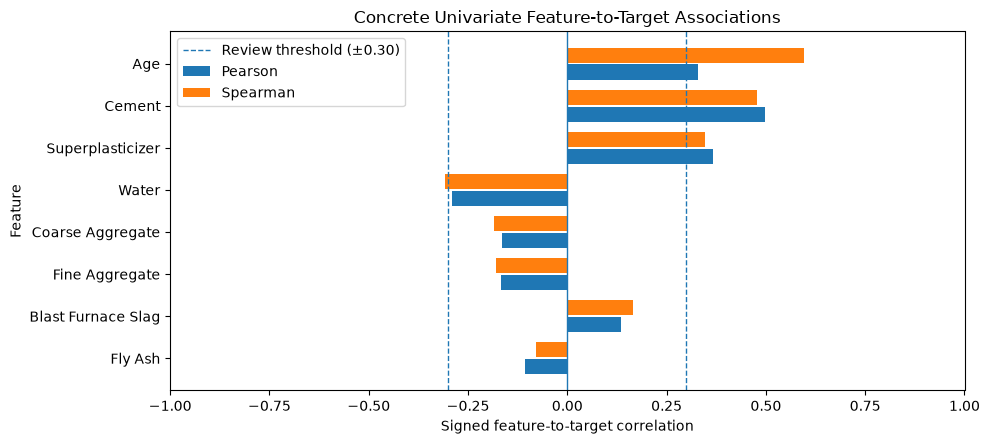

In [12]:
from scripts.analyze_target_relationships import (
    analyze_continuous_numerical_target_relationships,
    plot_continuous_feature_target_associations,
)
from scripts.export_figures import export_figure


# Exploratory association strength used for review, not feature selection.
CONTINUOUS_ASSOCIATION_REVIEW_THRESHOLD = 0.30

feature_target_report = analyze_continuous_numerical_target_relationships(
    df,
    features=NUMERICAL_FEATURES,
    target=target_contract.target,
    unit=TARGET_UNIT,
    association_review_threshold=CONTINUOUS_ASSOCIATION_REVIEW_THRESHOLD,
)

feature_target_report.raise_if_invalid(
    require_features_present=True,
    require_numeric_target=True,
    require_no_missing_target=True,
    require_target_variation=True,
    require_sufficient_feature_variation=True,
)

display(feature_target_report.summary_frame())
display(feature_target_report.relationships_frame())

association_figure = plot_continuous_feature_target_associations(
    feature_target_report,
    title="Concrete Univariate Feature-to-Target Associations",
)
export_figure(
    association_figure,
    PROJECT.root / "docs/images/feature_target_association_ranking.png",
)
display(association_figure)

if feature_target_report.has_review_candidates:
    print(
        "Review candidates show univariate linear or monotonic association "
        "only; no feature is selected or removed at this stage."
    )

## 14. Regression Structure, Nonlinearity, and Interaction Signals

## 15. Potential Data Leakage and Derived-Feature Dependencies

## 16. Initial Data-Quality Findings

## 17. Key Exploratory Insights

## 18. Preparation Decisions

## 19. Handoff and Next Steps